In [1]:
import pandas as pd
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
 
import torchmetrics
 
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
 
import optuna

d:\miniconda\envs\GradProject\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
class CNN(nn.Module):
    def __init__(self, n_layers, n_filters, kernel_sizes, dropout_rate, fc_size):
        super(CNN, self).__init__()

        # initilize an empty list to hold convolutional blocks
        blocks = []

        # the intitilization of input channels for RGB images
        in_channels = 3

        # loop in construct each block
        for i in range(n_layers):
            # get the parameters of the current layer
            out_channels = n_filters[i]
            kernel_size = kernel_sizes[i]
            # calculate padding
            padding = (kernel_size - 1) // 2

            block = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
            blocks.append(block)

            # Update the number of input channels for the next block
            in_channels = out_channels

        # combine the blocks into one extractor module
        self.features = nn.Sequential(*blocks)

        # Store hyperparameters needed for building the classifier
        self.dropout_rate = dropout_rate
        self.fc_size = fc_size

        # The classifier will be initialized dynamically in the forward pass
        self.classifier = None

    def _create_classifier(self, flattened_size, device):
        # Define the classifier's architecture
        self.classifier = nn.Sequential(
            nn.Dropout(self.dropout_rate),
            nn.Linear(flattened_size, self.fc_size),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate),
            nn.Linear(self.fc_size, 10)             # 10 output classes (CIFAR-10)
        ).to(device)

    def forward(self, x):
        # Get the device of the input tensor to ensure consistency
        device = x.device

        # pass the input through the feature extraction layer
        x = self.features(x)

        # Flatten the feature map to prepare it for the fully connected layers
        flattened = torch.flatten(x, 1)
        flattened_size = flattened.size(1)

        # If the classifier has not been created yet, initialize it
        if self.classifier is None:
            self._create_classifier(flattened_size, device)

        # Pass the flattened features through the classifier to get the final output
        return self.classifier(flattened)

In [4]:
def get_data_loaders_with_validation(batch_size, val_fraction=0.1):
    """Creates and returns data loaders for training, validation, and testing.

    Args:
        batch_size: The number of samples per batch in each data loader.
        val_fraction: The fraction of the training data to use for validation.

    Returns:
        A tuple containing the training, validation, and test data loaders.
    """
    # Define the transformations for the training data, including augmentation.
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Define the transformations for the validation and test data (no augmentation).
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load the full CIFAR-10 training dataset with the TRAIN transform.
    full_trainset = datasets.CIFAR10(root='./cifar10', train=True, download=True, transform=transform_train)
    
    # Load the full CIFAR-10 training dataset again with the TEST transform (for validation).
    # You need a separate object so the validation data doesn't get augmented.
    full_valset = datasets.CIFAR10(root='./cifar10', train=True, download=True, transform=transform_test)

    # Calculate the number of samples for the training and validation sets.
    total_train = len(full_trainset)
    val_size = int(val_fraction * total_train)
    train_size = total_train - val_size

    # Perform the split to generate random indices. 
    # You use full_trainset to generate the split, but you will apply indices to the correct backends below.
    train_subset_temp, val_subset_temp = random_split(full_trainset, [train_size, val_size])

    # Create the final train_set and val_set using the specific parent datasets and the generated indices.
    # This ensures train_set uses 'full_trainset' (augmented) and val_set uses 'full_valset' (not augmented).
    train_set = Subset(full_trainset, train_subset_temp.indices)
    val_set = Subset(full_valset, val_subset_temp.indices)

    # Load the CIFAR-10 test dataset.
    test_set = datasets.CIFAR10(root='./cifar10', train=False, download=True, transform=transform_test)

    # Create DataLoader instances for each dataset split.
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

    # Return the created data loaders.
    return train_loader, val_loader, test_loader

In [5]:
"""""
def train_model(model, optimizer, train_dataloader, n_epochs, loss_fcn, device):
    model.train()  # Set model to training mode

    for epoch in range(n_epochs):
        running_loss = 0.0
        total = 0
        correct = 0

        for inputs, labels in train_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass and
            outputs = model(inputs)
            loss = loss_fcn(outputs, labels)
            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Accumulate statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        print(f"Epoch [{epoch + 1}/{n_epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

    return model
"""""

'""\ndef train_model(model, optimizer, train_dataloader, n_epochs, loss_fcn, device):\n    model.train()  # Set model to training mode\n\n    for epoch in range(n_epochs):\n        running_loss = 0.0\n        total = 0\n        correct = 0\n\n        for inputs, labels in train_dataloader:\n            inputs, labels = inputs.to(device), labels.to(device)\n\n            # Zero the parameter gradients\n            optimizer.zero_grad()\n            # Forward pass and\n            outputs = model(inputs)\n            loss = loss_fcn(outputs, labels)\n            # Backward pass and optimization\n            loss.backward()\n            optimizer.step()\n\n            # Accumulate statistics\n            running_loss += loss.item() * inputs.size(0)\n            _, predicted = torch.max(outputs, dim=1)\n            total += labels.size(0)\n            correct += (predicted == labels).sum().item()\n\n        epoch_loss = running_loss / total\n        epoch_acc = correct / total\n        pri

In [6]:
@torch.no_grad()
def evaluate_model(model, dataloader, device):
    model.eval()
    total = 0
    correct = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return correct / total

In [7]:
def train_and_evaluate(model, optimizer, scheduler, device, n_epochs, train_loader, val_loader):
    """Trains a model for a number of epochs, evaluating on the validation set
    after each epoch, and steps a learning rate scheduler.

    Args:
        model: The neural network to train.
        optimizer: The optimizer used to update model parameters.
        scheduler: A learning rate scheduler (e.g. StepLR, CosineAnnealingLR, etc.).
        device: The device to run training on ('cuda' or 'cpu').
        n_epochs: Number of epochs to train for.
        train_loader: DataLoader for the training set.
        val_loader: DataLoader for the validation set.

    Returns:
        A tuple (model, history) where history is a dict containing
        per-epoch train_loss, train_acc, and val_acc lists.
    """
    loss_fcn = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(n_epochs):
        # ----- Training phase -----
        model.train()
        running_loss = 0.0
        total = 0
        correct = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fcn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # ----- Validation phase -----
        val_acc = evaluate_model(model, val_loader, device)

        # ----- Scheduler step -----
        # Handles both standard schedulers and ReduceLROnPlateau,
        # which needs a metric passed in.
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_acc)
        else:
            scheduler.step()

        # ----- Logging -----
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch [{epoch + 1}/{n_epochs}] - "
              f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - "
              f"Val Acc: {val_acc:.4f} - LR: {current_lr:.6f}")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return model, history

In [8]:
def plot_training_history(history, title="Training History"):
    """Plots training loss and train/validation accuracy curves side by side.
 
    Args:
        history: Dict with keys 'train_loss', 'train_acc', 'val_acc', each
            a list of per-epoch values (as returned by train_and_evaluate).
        title: Overall figure title.
    """
    epochs = range(1, len(history["train_loss"]) + 1)
 
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
 
    # Loss curve
    axes[0].plot(epochs, history["train_loss"], marker='o', label="Train Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
 
    # Accuracy curves
    axes[1].plot(epochs, history["train_acc"], marker='o', label="Train Accuracy")
    axes[1].plot(epochs, history["val_acc"], marker='o', label="Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Train vs. Validation Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
 
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

# Optuna Objective Function

In [9]:
def objective(trial, device, train_loader, val_loader):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    n_filters = [trial.suggest_int(f"n_filters_{i}", 16, 128) for i in range(n_layers)]
    kernel_sizes = [trial.suggest_categorical(f"kernel_size_{i}", [3, 5]) for i in range(n_layers)]

    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    fc_size = trial.suggest_int("fc_size", 64, 256)

    model = CNN(n_layers, n_filters, kernel_sizes, dropout_rate, fc_size).to(device)

    dummy_input = torch.randn(1, 3, 32, 32).to(device)
    model(dummy_input)

    learning_rate = 0.01
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    n_epochs = trial.suggest_int("n_epochs", 3, 10)

    # Scheduler decays LR smoothly to 0 over the course of training
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    model, history = train_and_evaluate(
        model, optimizer, scheduler, device, n_epochs, train_loader, val_loader
    )

    # Optuna optimizes the final epoch's validation accuracy
    val_accuracy = history["val_acc"][-1]

    return val_accuracy

In [11]:
# Build the dataloaders once, outside the objective, so every trial reuses them
train_loader, val_loader, test_loader = get_data_loaders_with_validation(batch_size=128)

print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))

100%|██████████| 170M/170M [33:57<00:00, 83.7kB/s] 


Extracting ./cifar10\cifar-10-python.tar.gz to ./cifar10
Files already downloaded and verified
Files already downloaded and verified
45000
5000
10000


In [12]:
# Create an Optuna study to search for the best hyperparameters,
# maximizing the objective's return value (validation accuracy)
study = optuna.create_study(direction='maximize')

# Number of different hyperparameter combinations to try
n_trials = 20

# Run the optimization loop:
# - For each trial, Optuna calls objective(trial, device, train_loader, val_loader)
# - The lambda binds device/train_loader/val_loader so they're reused across trials
#   without being recreated on every call
# - Optuna uses the returned val_accuracy to decide which hyperparameters to try next
study.optimize(
    lambda trial: objective(trial, device, train_loader, val_loader),
    n_trials=n_trials
)

[I 2026-08-14 12:22:57,488] A new study created in memory with name: no-name-557df510-bef7-4053-9f22-ad1a30d60628


Epoch [1/4] - Train Loss: 2.3288 - Train Acc: 0.0993 - Val Acc: 0.0984 - LR: 0.008536
Epoch [2/4] - Train Loss: 2.3033 - Train Acc: 0.1002 - Val Acc: 0.0956 - LR: 0.005000
Epoch [3/4] - Train Loss: 2.3030 - Train Acc: 0.0982 - Val Acc: 0.0956 - LR: 0.001464


[I 2026-08-14 12:24:08,123] Trial 0 finished with value: 0.0956 and parameters: {'n_layers': 3, 'n_filters_0': 51, 'n_filters_1': 96, 'n_filters_2': 114, 'kernel_size_0': 3, 'kernel_size_1': 5, 'kernel_size_2': 3, 'dropout_rate': 0.35296480141664754, 'fc_size': 114, 'n_epochs': 4}. Best is trial 0 with value: 0.0956.


Epoch [4/4] - Train Loss: 2.3028 - Train Acc: 0.0997 - Val Acc: 0.0956 - LR: 0.000000
Epoch [1/3] - Train Loss: 2.3413 - Train Acc: 0.1373 - Val Acc: 0.1742 - LR: 0.007500
Epoch [2/3] - Train Loss: 2.1573 - Train Acc: 0.1740 - Val Acc: 0.1822 - LR: 0.002500


[I 2026-08-14 12:24:58,859] Trial 1 finished with value: 0.246 and parameters: {'n_layers': 2, 'n_filters_0': 62, 'n_filters_1': 79, 'kernel_size_0': 5, 'kernel_size_1': 5, 'dropout_rate': 0.33752012137231346, 'fc_size': 73, 'n_epochs': 3}. Best is trial 1 with value: 0.246.


...

Epoch [8/8] - Train Loss: 1.6533 - Train Acc: 0.3718 - Val Acc: 0.5064 - LR: 0.000000
Epoch [1/9] - Train Loss: 2.0803 - Train Acc: 0.2246 - Val Acc: 0.3282 - LR: 0.009698
Epoch [2/9] - Train Loss: 1.8398 - Train Acc: 0.3154 - Val Acc: 0.3952 - LR: 0.008830
Epoch [3/9] - Train Loss: 1.7619 - Train Acc: 0.3498 - Val Acc: 0.4150 - LR: 0.007500
Epoch [4/9] - Train Loss: 1.7151 - Train Acc: 0.3610 - Val Acc: 0.4380 - LR: 0.005868
Epoch [5/9] - Train Loss: 1.6719 - Train Acc: 0.3818 - Val Acc: 0.4438 - LR: 0.004132
Epoch [6/9] - Train Loss: 1.6230 - Train Acc: 0.3988 - Val Acc: 0.4592 - LR: 0.002500
Epoch [7/9] - Train Loss: 1.5890 - Train Acc: 0.4097 - Val Acc: 0.4850 - LR: 0.001170
Epoch [8/9] - Train Loss: 1.5485 - Train Acc: 0.4331 - Val Acc: 0.4948 - LR: 0.000302


[I 2026-08-14 13:03:57,146] Trial 18 finished with value: 0.5002 and parameters: {'n_layers': 2, 'n_filters_0': 36, 'n_filters_1': 128, 'kernel_size_0': 3, 'kernel_size_1': 3, 'dropout_rate': 0.24418609606601607, 'fc_size': 174, 'n_epochs': 9}. Best is trial 15 with value: 0.5908.


Epoch [9/9] - Train Loss: 1.5197 - Train Acc: 0.4408 - Val Acc: 0.5002 - LR: 0.000000
Epoch [1/7] - Train Loss: 1.9862 - Train Acc: 0.2668 - Val Acc: 0.3656 - LR: 0.009505
Epoch [2/7] - Train Loss: 1.7682 - Train Acc: 0.3314 - Val Acc: 0.3672 - LR: 0.008117
Epoch [3/7] - Train Loss: 1.7079 - Train Acc: 0.3539 - Val Acc: 0.3924 - LR: 0.006113
Epoch [4/7] - Train Loss: 1.6289 - Train Acc: 0.3905 - Val Acc: 0.4454 - LR: 0.003887
Epoch [5/7] - Train Loss: 1.5765 - Train Acc: 0.4132 - Val Acc: 0.4766 - LR: 0.001883
Epoch [6/7] - Train Loss: 1.5146 - Train Acc: 0.4359 - Val Acc: 0.5072 - LR: 0.000495


[I 2026-08-14 13:05:54,544] Trial 19 finished with value: 0.5098 and parameters: {'n_layers': 1, 'n_filters_0': 22, 'kernel_size_0': 5, 'dropout_rate': 0.1500129808814561, 'fc_size': 123, 'n_epochs': 7}. Best is trial 15 with value: 0.5908.


Epoch [7/7] - Train Loss: 1.4785 - Train Acc: 0.4505 - Val Acc: 0.5098 - LR: 0.000000


In [13]:
# # Retrain the Best Model

# Optuna trials are trained for very few epochs to keep the search fast. Now that
# we know which hyperparameters work best, retrain that architecture for longer
# so we get a properly converged model before touching the test set.
best_params = study.best_params
print("Best hyperparameters:", best_params)

Best hyperparameters: {'n_layers': 1, 'n_filters_0': 16, 'kernel_size_0': 3, 'dropout_rate': 0.1085233603240336, 'fc_size': 129, 'n_epochs': 8}


In [14]:
# Rebuild the model architecture using the best trial's hyperparameters
n_layers = best_params["n_layers"]
n_filters = [best_params[f"n_filters_{i}"] for i in range(n_layers)]
kernel_sizes = [best_params[f"kernel_size_{i}"] for i in range(n_layers)]
dropout_rate = best_params["dropout_rate"]
fc_size = best_params["fc_size"]
 
best_model = CNN(n_layers, n_filters, kernel_sizes, dropout_rate, fc_size).to(device)
 
# Initialize the dynamic classifier
dummy_input = torch.randn(1, 3, 32, 32).to(device)
best_model(dummy_input)

tensor([[ 0.3596, -0.1465,  0.2352, -0.0408,  0.1986, -0.1547,  0.2245,  0.6021,
         -0.0398,  0.0626]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [15]:
# Retrain for longer than the search allowed, with a scheduler.
# Note: rather than reusing best_params["n_epochs"] (which was tuned for a fast
# search), we pick a more generous fixed epoch budget for the final model.
final_epochs = 30
optimizer = optim.Adam(best_model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=final_epochs)
 
best_model, history = train_and_evaluate(
    best_model, optimizer, scheduler, device, final_epochs, train_loader, val_loader
)

Epoch [1/30] - Train Loss: 1.8637 - Train Acc: 0.3142 - Val Acc: 0.4112 - LR: 0.009973
Epoch [2/30] - Train Loss: 1.6681 - Train Acc: 0.3849 - Val Acc: 0.4742 - LR: 0.009891
Epoch [3/30] - Train Loss: 1.6248 - Train Acc: 0.4073 - Val Acc: 0.4664 - LR: 0.009755
Epoch [4/30] - Train Loss: 1.5936 - Train Acc: 0.4152 - Val Acc: 0.5076 - LR: 0.009568
Epoch [5/30] - Train Loss: 1.5767 - Train Acc: 0.4261 - Val Acc: 0.4840 - LR: 0.009330
Epoch [6/30] - Train Loss: 1.5581 - Train Acc: 0.4332 - Val Acc: 0.5238 - LR: 0.009045
Epoch [7/30] - Train Loss: 1.5477 - Train Acc: 0.4407 - Val Acc: 0.5260 - LR: 0.008716
Epoch [8/30] - Train Loss: 1.5242 - Train Acc: 0.4487 - Val Acc: 0.5376 - LR: 0.008346
Epoch [9/30] - Train Loss: 1.5181 - Train Acc: 0.4515 - Val Acc: 0.5236 - LR: 0.007939
Epoch [10/30] - Train Loss: 1.4926 - Train Acc: 0.4641 - Val Acc: 0.5326 - LR: 0.007500
Epoch [11/30] - Train Loss: 1.4868 - Train Acc: 0.4641 - Val Acc: 0.5506 - LR: 0.007034
Epoch [12/30] - Train Loss: 1.4691 - Trai

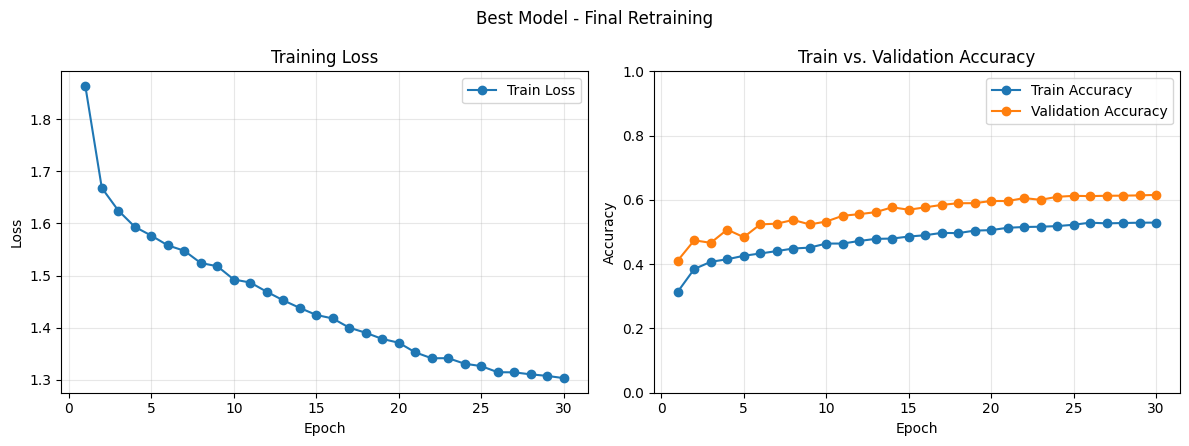

In [16]:
# Visualize the training and validation curves to sanity-check convergence and overfitting
plot_training_history(history, title="Best Model - Final Retraining")

In [17]:
# Finally, evaluate on the held-out test set
test_accuracy = evaluate_model(best_model, test_loader, device)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.6126
